<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/Seaborn_Analytics_Mastery_End_to_End_Exploratory_Data_Visualization_and_Statistical_Insight_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10,6)

In [4]:
tips = sns.load_dataset('tips')
titanic = sns.load_dataset('titanic')
flights = sns.load_dataset('flights')
penguins = sns.load_dataset('penguins')

In [5]:
def overview(df, name):
  print(f"\n{name} Dataset")
  print("-"*40)
  print(df.head())
  print("\nShape:",df.shape)
  print("\nMissing Values:\n",df.isnull().sum())

overview(tips,"Tips")
overview(titanic,"Titanic")
overview(flights,"Flights")
overview(penguins,"Penguins")


Tips Dataset
----------------------------------------
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Shape: (244, 7)

Missing Values:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Titanic Dataset
----------------------------------------
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    

In [6]:
titanic = titanic.dropna(subset=['age','embark_town'])
penguins = penguins.dropna()

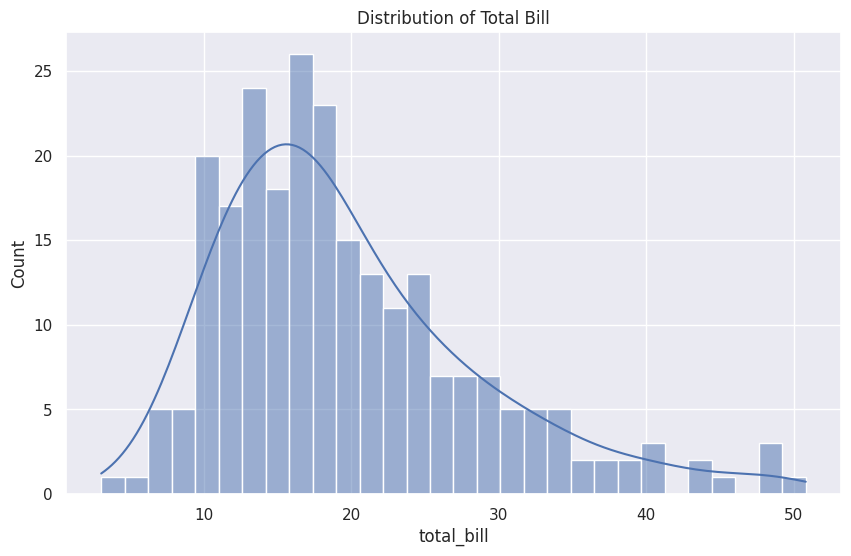

In [7]:
sns.histplot(tips["total_bill"], kde=True, bins=30)
plt.title("Distribution of Total Bill")
plt.show()

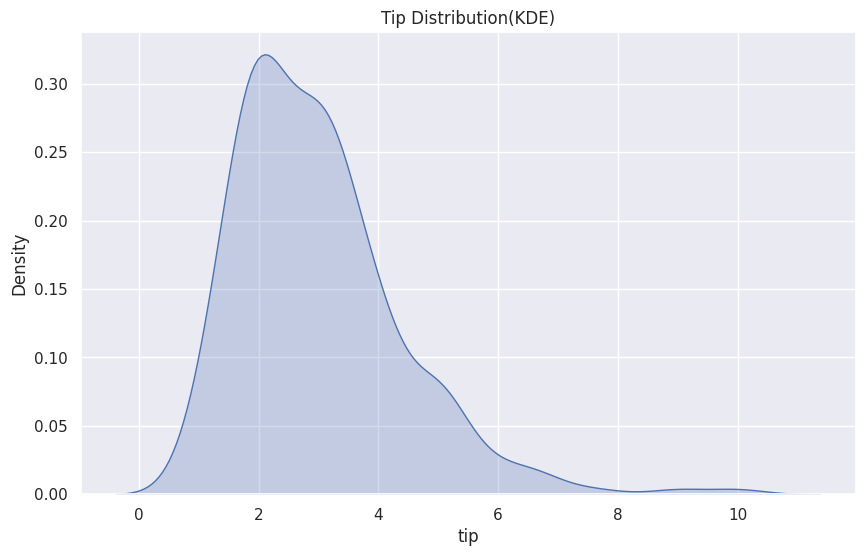

In [8]:
sns.kdeplot(tips['tip'],fill=True)
plt.title("Tip Distribution(KDE)")
plt.show()

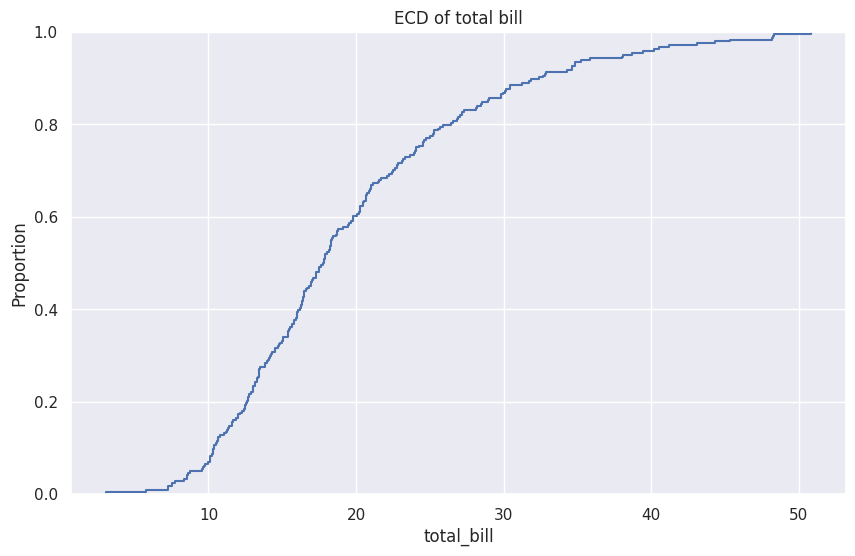

In [9]:
sns.ecdfplot(tips["total_bill"])
plt.title('ECD of total bill')
plt.show()

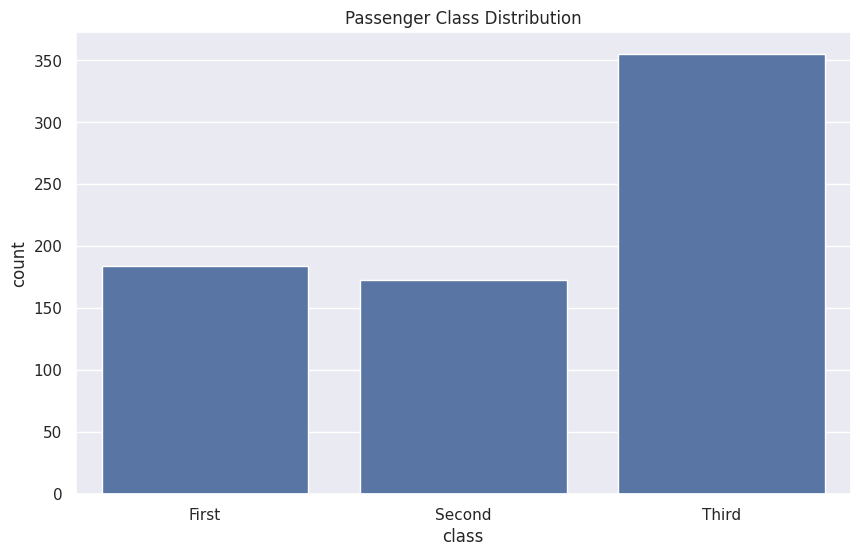

In [11]:
sns.countplot(data=titanic, x='class')
plt.title('Passenger Class Distribution')
plt.show()

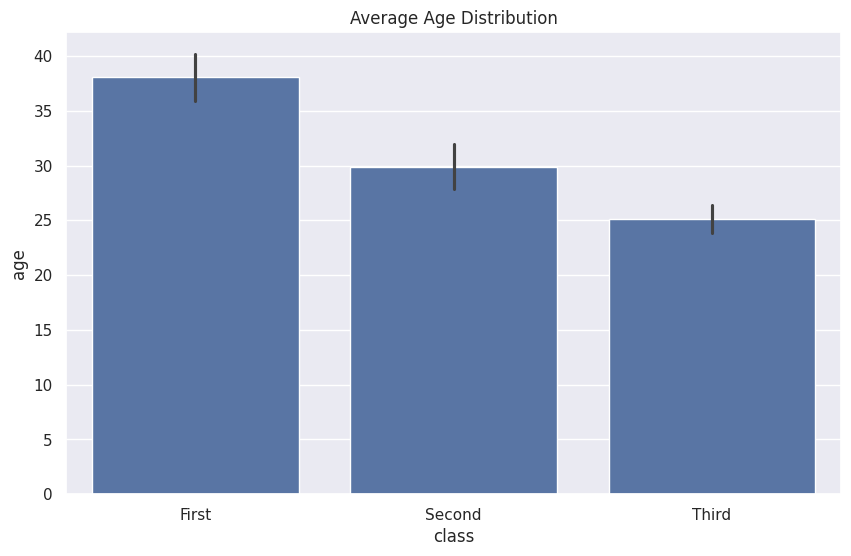

In [12]:
sns.barplot(data=titanic, x='class', y='age')
plt.title('Average Age Distribution')
plt.show()

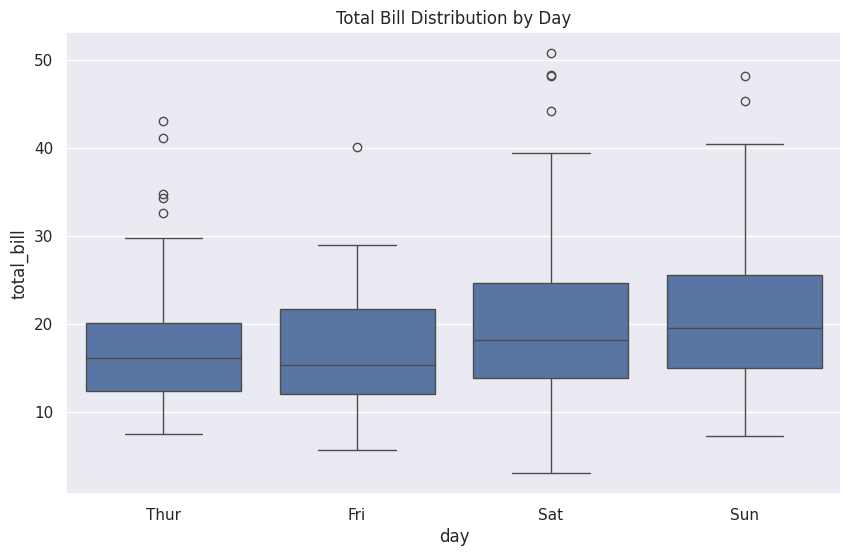

In [13]:
sns.boxplot(data=tips, x='day', y='total_bill')
plt.title('Total Bill Distribution by Day')
plt.show()

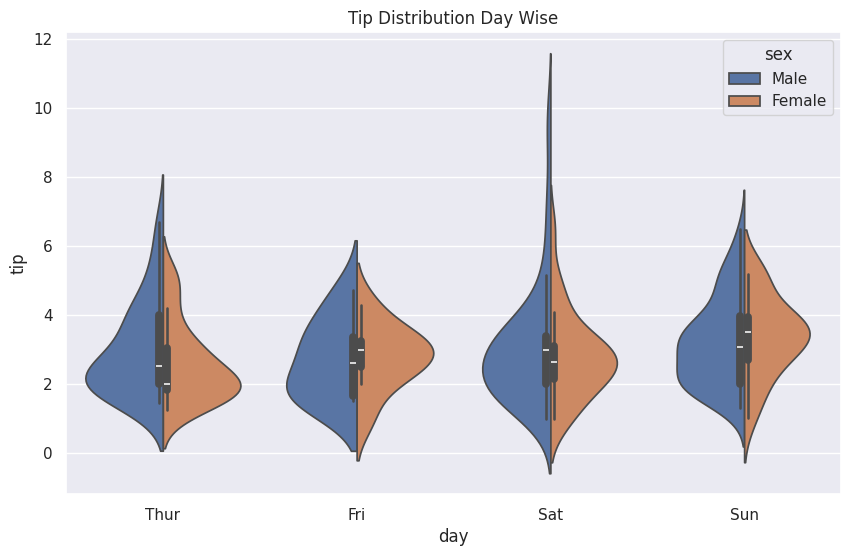

In [14]:
sns.violinplot(data=tips, x='day', y='tip',hue='sex',split=True)
plt.title("Tip Distribution Day Wise")
plt.show()

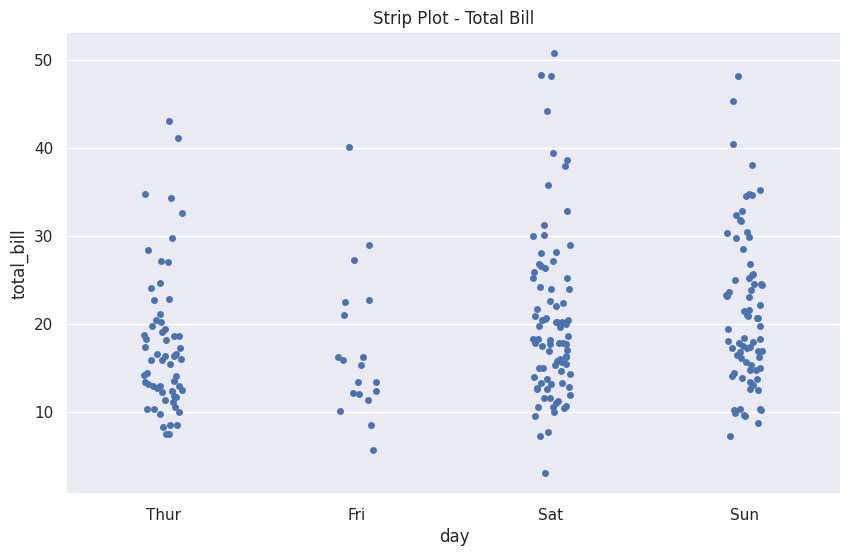

In [15]:
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True)
plt.title("Strip Plot - Total Bill")
plt.show()

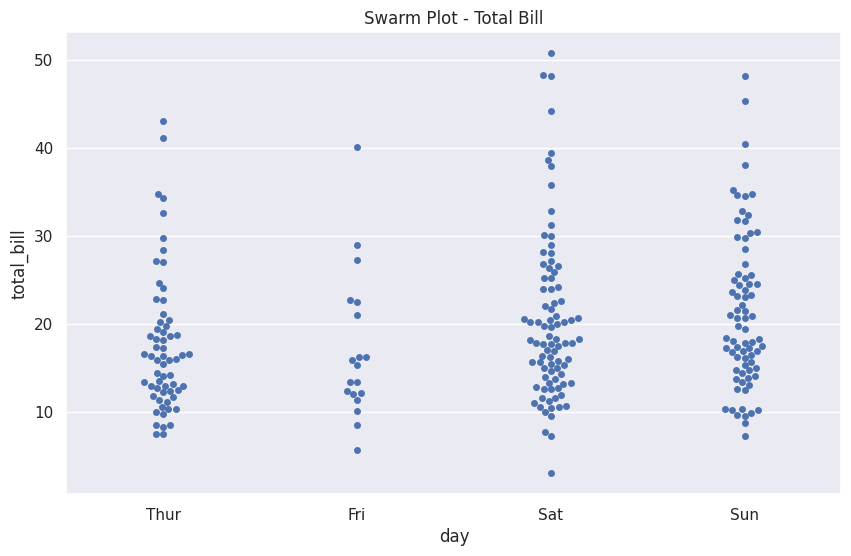

In [16]:
sns.swarmplot(data=tips, x='day', y='total_bill')
plt.title("Swarm Plot - Total Bill")
plt.show()

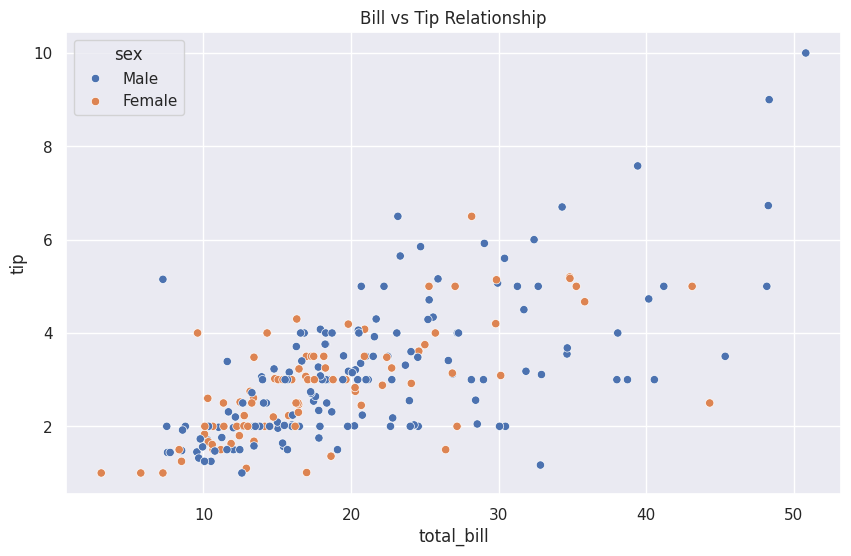

In [17]:
#SCATTER PLOT
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex')
plt.title('Bill vs Tip Relationship')
plt.show()

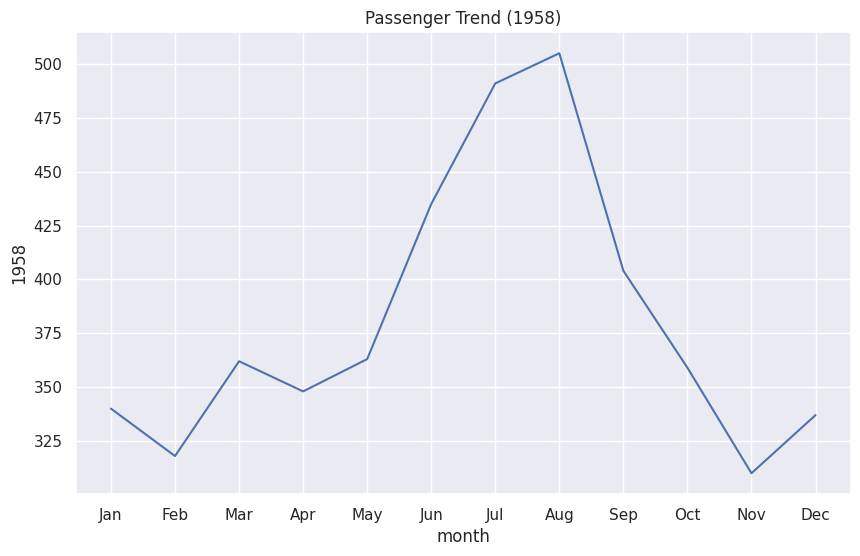

In [18]:
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

sns.lineplot(data=flights_pivot[1958])
plt.title("Passenger Trend (1958)")
plt.show()

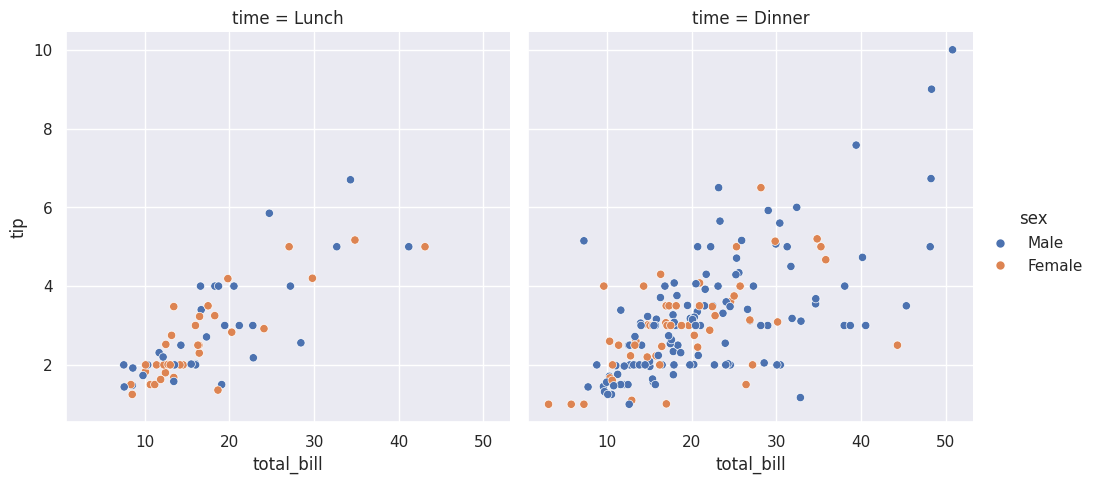

In [19]:
sns.relplot(data=tips, x="total_bill", y="tip", hue="sex", col="time")
plt.show()

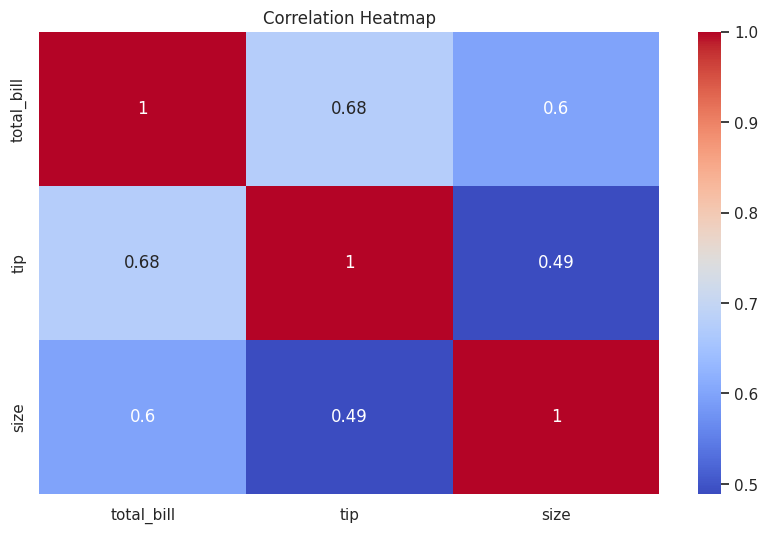

In [20]:
corr = tips.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

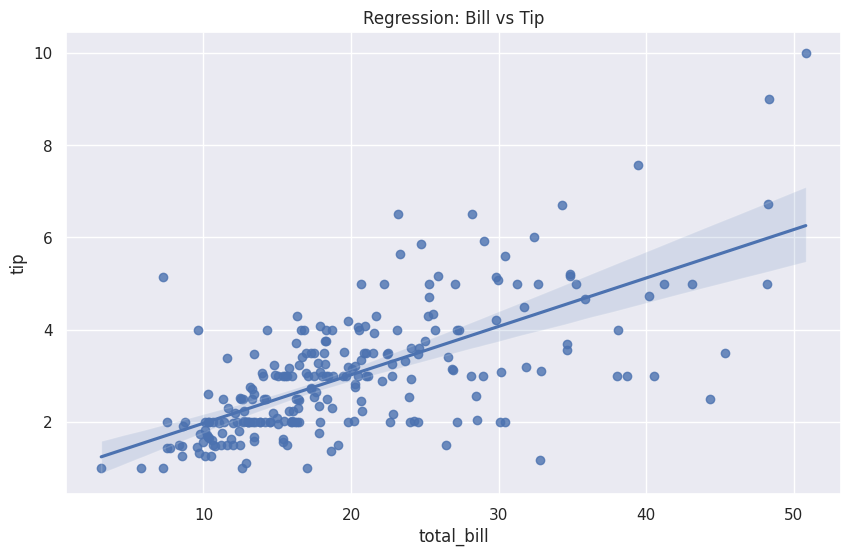

In [21]:
sns.regplot(data=tips, x="total_bill", y="tip")
plt.title("Regression: Bill vs Tip")
plt.show()

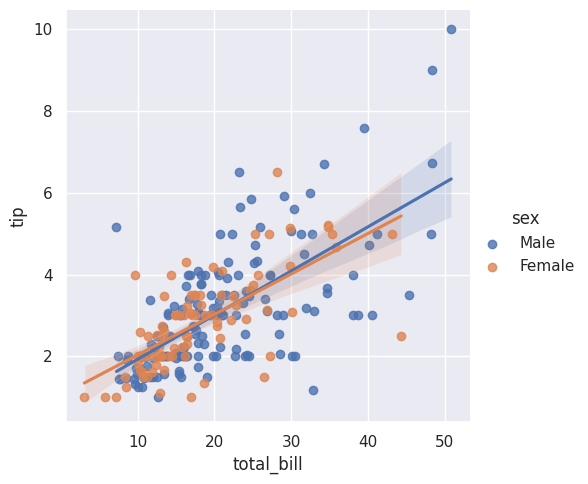

In [22]:
sns.lmplot(data=tips, x="total_bill", y="tip", hue="sex")
plt.show()

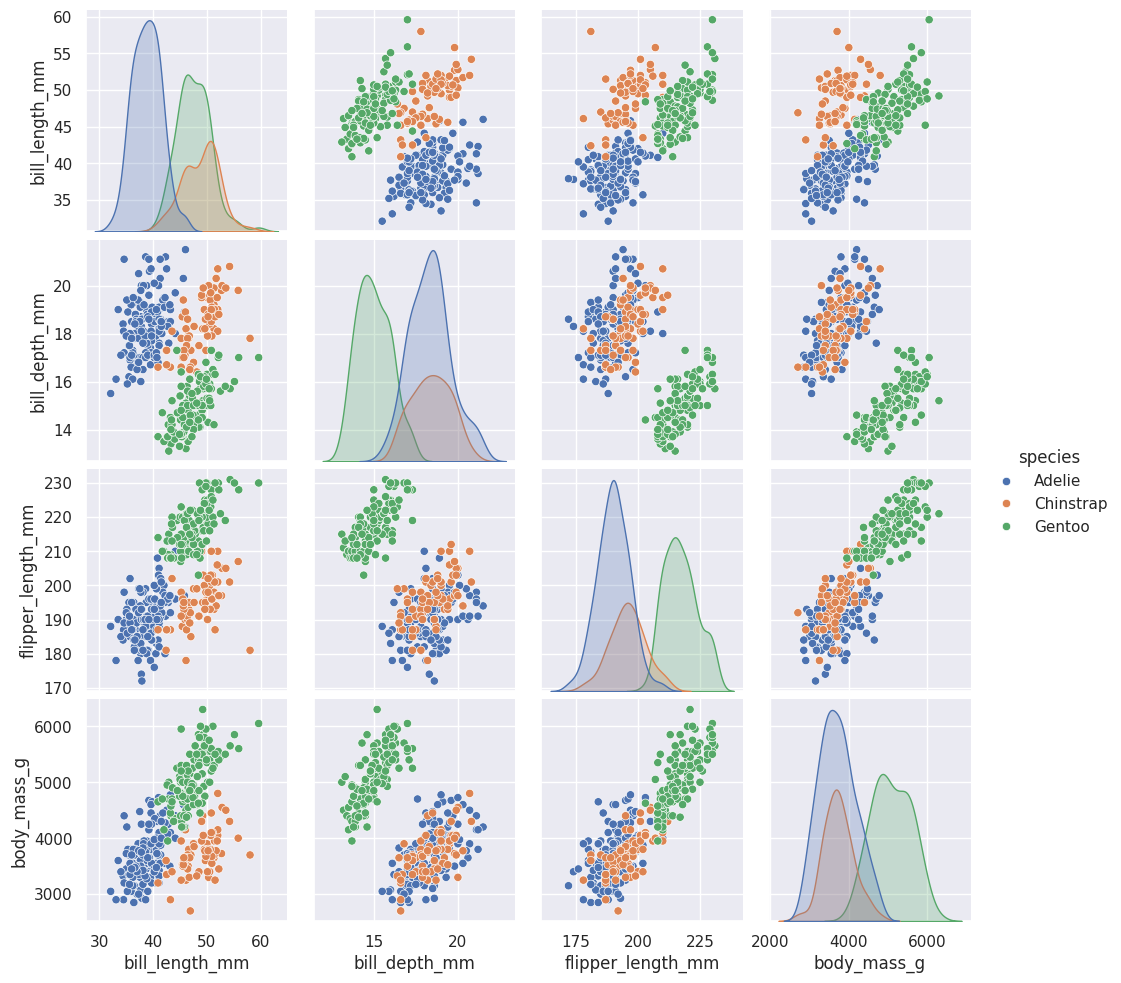

In [23]:
sns.pairplot(penguins, hue="species")
plt.show()

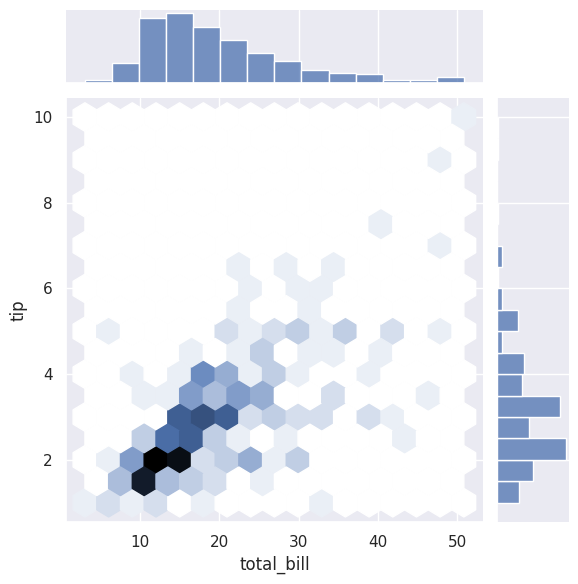

In [24]:
sns.jointplot(data=tips, x="total_bill", y="tip", kind="hex")
plt.show()

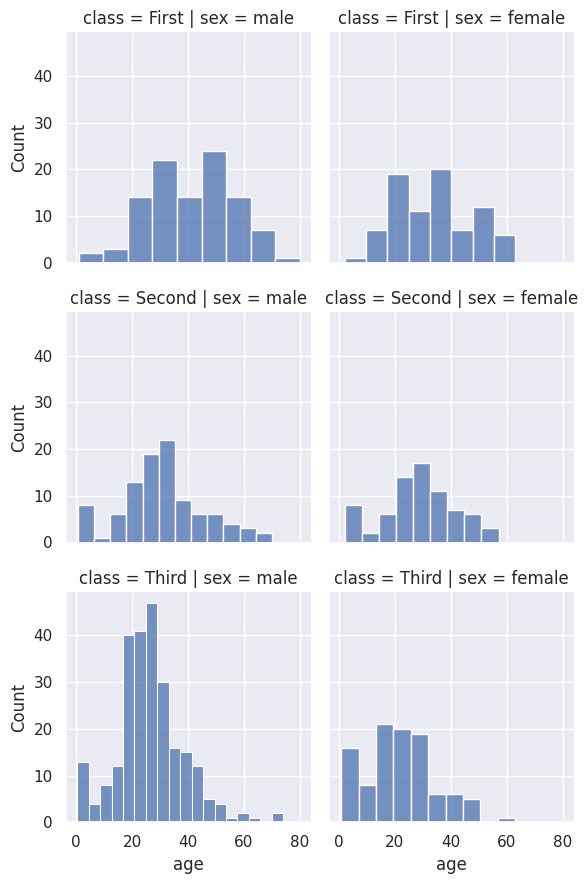

In [25]:
g = sns.FacetGrid(titanic, col="sex", row="class")
g.map_dataframe(sns.histplot, x="age")
plt.show()

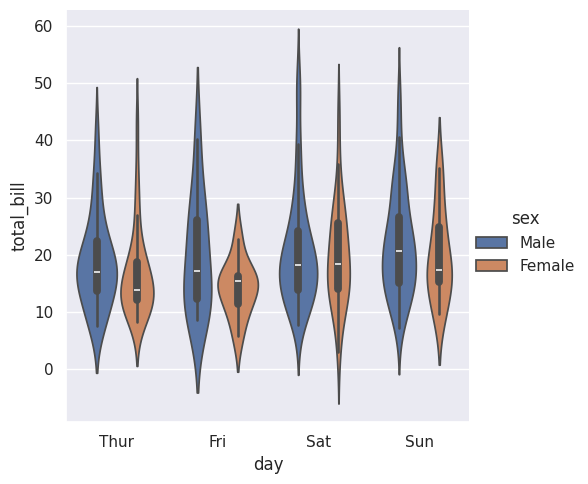

In [26]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", kind="violin")
plt.show()

In [27]:
def insight_summary(df, col):
    print(f"\n📊 Insights for {col}")
    print("-"*40)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Skewness:", df[col].skew())
    print("Std Dev:", df[col].std())

insight_summary(tips, "total_bill")


📊 Insights for total_bill
----------------------------------------
Mean: 19.78594262295082
Median: 17.795
Skewness: 1.1332130376158205
Std Dev: 8.902411954856856


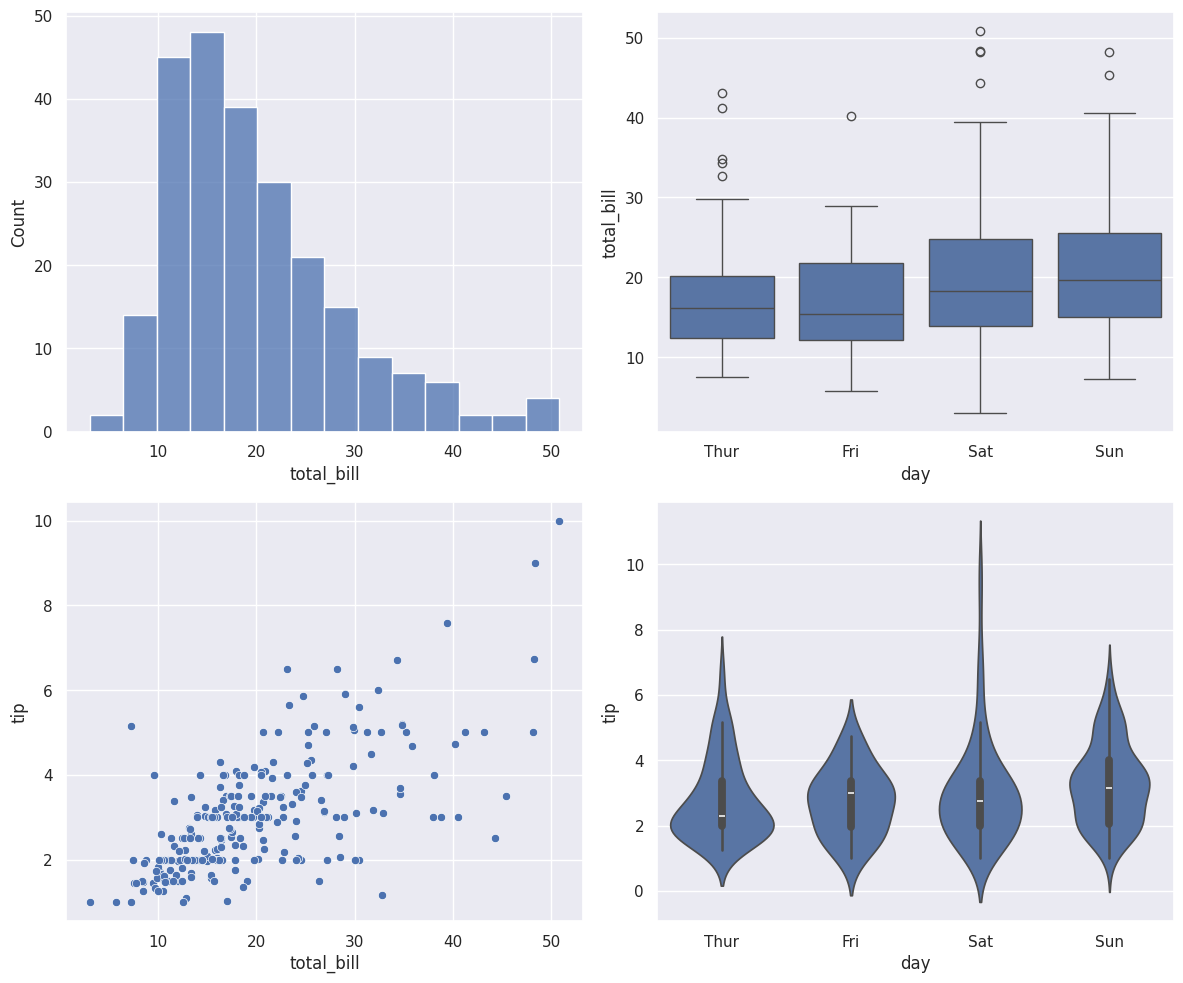

In [28]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.histplot(tips["total_bill"], ax=axes[0,0])
sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[0,1])
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=axes[1,0])
sns.violinplot(data=tips, x="day", y="tip", ax=axes[1,1])

plt.tight_layout()
plt.show()

In [29]:
print("""
📌 KEY INSIGHTS:
1. Higher bills tend to generate higher tips (positive correlation)
2. Male customers slightly spend more on average
3. Weekend days show higher variability in bills
4. First class passengers are generally older
""")


📌 KEY INSIGHTS:
1. Higher bills tend to generate higher tips (positive correlation)
2. Male customers slightly spend more on average
3. Weekend days show higher variability in bills
4. First class passengers are generally older

